# Chapter 0: Introduction

This project focuses on predicting the salaries of professional baseball players using statistical and machine learning techniques. The dataset contains a mix of current-season performance metrics, career totals, and categorical information related to player league and division. Salary prediction is an important problem in sports analytics because it helps teams evaluate player value, identify underpaid talent, and optimize roster decisions.
In this notebook, we begin our analysis with Exploratory Data Analysis (EDA). The primary goals of this section are:

-To understand the structure of the dataset and the meaning of each variable
-To identify missing values and determine whether imputation or filtering is required
-To examine the distribution of Salary and log(Salary)
-To visualize relationships between player performance metrics and earnings
-To compute correlations between key features and the target variable

At the end of this notebook, we produce a cleaned version of the dataset that will be used for the rest of the project.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
pd.set_option('display.max_columns', 100)

## 0.1 Outline

0. Introduction
Purpose of the project: predict baseball player's salaries


1. Exploratory Data Analysis (EDA)
1.1 Overview
Structure of the dataset
Summary stats for performance metrics and salary
1.2 Missing Values
Salary missingness
Missing patterns in other variables
1.3 Target Variable Exploration
Distribution of Salary
Distribution of log(Salary)
Compare skewness before/after log transform
1.4 Correlations
Correlation matrix for numerical features
Identify strongest predictors of salary
1.5 Salary Distribution Across Features
1.5.1 Continuous Features
Salary/log-salary vs Hits, Runs, Years, CAtBat, etc.
1.5.2 Categorical Features
Salary differences by League, Division, NewLeague
1.6 EDA Conclusion
Which features matter most
Whether classification tiers or log-salary seem appropriate
Which features may require transformation

2. Feature Engineering
2.1 Transforming the Target
2.1.1 Log-Salary
Why log transform is beneficial
When to model log-salary instead of salary
2.1.2 Salary Tier Classification
Define bins: Low / Mid / High
Compare quantile binning vs fixed ranges
2.2 Scaling & Normalization (for gradient descent models)
Why linear models with gradient descent benefit from scaling
2.3 Encoding Categorical Variables
Turning League, Division, NewLeague into numeric variables
One-hot encoding (simple version)
2.4 Optional Feature Engineering
Add ratios (Hits/AtBat → batting average)
Consider interaction features (Hits × Years)
Keep this section optional and simple
2.5 Feature Engineering Conclusion
Final decisions on transformations used for modeling


# Chapter 1: QA (Quality Assurance) & EDA (Exploratory Data Analysis)

## 1.1 Data Acquisition

In [8]:
baseball_train = pd.read_csv("C:\\Users\\jawad\\OneDrive\\Documents\\GitHub\\ML_Final_Project\\data_sets\\Baseball_train.csv")
print("Sucessfully imported train baeball data")

Sucessfully imported train baeball data


In [9]:
baseball_test = pd.read_csv("C:\\Users\\jawad\\OneDrive\\Documents\\GitHub\\ML_Final_Project\\data_sets\\Baseball_test.csv")
print("Sucessfully imported test baeball data")

Sucessfully imported test baeball data


## 1.2 Descriptive Statistics

In [11]:
baseball_train.info(verbose = True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35 non-null     int64  
 1   Name        35 non-null     object 
 2   AtBat       35 non-null     int64  
 3   Hits        35 non-null     int64  
 4   HmRun       35 non-null     int64  
 5   Runs        35 non-null     int64  
 6   RBI         35 non-null     int64  
 7   Walks       35 non-null     int64  
 8   Years       35 non-null     int64  
 9   CAtBat      35 non-null     int64  
 10  CHits       35 non-null     int64  
 11  CHmRun      35 non-null     int64  
 12  CRuns       35 non-null     int64  
 13  CRBI        35 non-null     int64  
 14  CWalks      35 non-null     int64  
 15  League      35 non-null     object 
 16  Division    35 non-null     object 
 17  PutOuts     35 non-null     int64  
 18  Assists     35 non-null     int64  
 19  Errors      35 non-null     int

The dataset consists only 35 entries, thus would not be friendly to subsetting.

In [13]:
baseball_train.sample(3)

,Unnamed: 0,Name,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
8,234,-Paul Molitor,437,123,9,62,55,40,9,4139,1203,79,676,390,364,A,E,82,170,15,1260.0,A
23,77,-Danny Heep,195,55,5,24,33,30,8,1313,338,25,144,149,153,N,E,83,2,1,NaN,N
13,235,-Pete O'Brien,551,160,23,86,90,87,5,2235,602,75,278,328,273,A,W,1224,115,11,NaN,A


#### Features

Dictionary / Features Identified:
Player identifiers: Name, League, Division, NewLeague

Current season stats: AtBat, Hits, HmRun, Runs, RBI, Walks, PutOuts, Assists, Errors

Career totals: CAtBat, CHits, CHmRun, CRuns, CRBI, CWalks, Years

Target: Salary

In [16]:
baseball_train = baseball_train.drop(columns=['Unnamed: 0']) #Drop the unnamed column

In [17]:
baseball_train.describe()#(include='all')

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,23.000000
mean,370.485714,97.400000,9.714286,49.457143,45.342857,36.371429,6.771429,2344.571429,625.428571,60.828571,316.285714,279.628571,227.457143,278.942857,87.942857,7.057143,451.159435
std,160.738072,45.770656,8.810326,25.095515,25.088013,20.970688,4.965088,2023.709658,540.732634,87.033626,273.418616,282.395747,219.849593,294.470606,133.212555,6.009516,396.810733
min,19.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,41.000000,13.000000,0.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,70.000000
25%,216.000000,56.000000,2.000000,31.000000,28.500000,22.500000,2.500000,619.500000,160.500000,8.000000,79.500000,55.500000,53.500000,94.500000,6.500000,2.500000,152.500000
50%,401.000000,100.000000,7.000000,53.000000,44.000000,33.000000,6.000000,1416.000000,398.000000,31.000000,210.000000,198.000000,167.000000,233.000000,15.000000,5.000000,297.500000
75%,505.500000,129.000000,15.000000,69.000000,54.000000,44.500000,11.000000,3806.500000,1022.500000,81.500000,536.500000,424.500000,328.500000,305.500000,137.500000,11.000000,637.500000
max,627.000000,177.000000,35.000000,98.000000,100.000000,87.000000,18.000000,7318.000000,1926.000000,442.000000,901.000000,1210.000000,866.000000,1224.000000,482.000000,22.000000,1350.000000


In [18]:
baseball_train.nunique()

Name         35
AtBat        31
Hits         31
HmRun        20
Runs         30
RBI          26
Walks        25
Years        15
CAtBat       34
CHits        35
CHmRun       31
CRuns        35
CRBI         32
CWalks       34
League        2
Division      2
PutOuts      33
Assists      28
Errors       16
Salary       22
NewLeague     2
dtype: int64

## 1.3 Handling Missing Values

Since we know that our dataset is only 35 rows, dropping any null rows greater than 5-10% of the dataset is a risk to data integrity. 
Thus, we cannot execute df_baseball_train = df_baseball_train.dropna(subset=['Salary']).reset_index(drop=True)

In [21]:
baseball_train.isnull().sum()

Name          0
AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       12
NewLeague     0
dtype: int64

In [22]:
nulls = baseball_train[baseball_train['Salary'].isna()]
nulls

,Name,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Bruce Bochte,407,104,6,57,43,65,12,5233,1478,100,643,658,653,A,W,912,88,9,NaN,A
1,-Bill Russell,216,54,0,21,18,15,18,7318,1926,46,796,627,483,N,W,103,84,5,NaN,N
2,-Doug Baker,24,3,0,1,0,2,3,159,28,0,20,12,9,A,W,80,4,0,NaN,A
3,-Rudy Law,307,80,1,42,36,29,7,2421,656,18,379,198,184,A,W,145,2,2,NaN,A
9,-Dave Kingman,561,118,35,70,94,33,16,6677,1575,442,901,1210,608,A,W,463,32,8,NaN,A
13,-Pete O'Brien,551,160,23,86,90,87,5,2235,602,75,278,328,273,A,W,1224,115,11,NaN,A
15,-Franklin Stubbs,420,95,23,55,58,37,3,646,139,31,77,77,61,N,W,206,10,7,NaN,N
18,-Joe Orsulak,401,100,2,60,19,28,4,876,238,2,126,44,55,N,E,193,11,4,NaN,N
23,-Danny Heep,195,55,5,24,33,30,8,1313,338,25,144,149,153,N,E,83,2,1,NaN,N
24,-Cliff Johnson,19,7,0,1,2,1,4,41,13,1,3,4,4,A,E,0,0,0,NaN,A


In [23]:
baseball_train["Salary"].describe() # Train salary (with null)

count      23.000000
mean      451.159435
std       396.810733
min        70.000000
25%       152.500000
50%       297.500000
75%       637.500000
max      1350.000000
Name: Salary, dtype: float64

<BarContainer object of 35 artists>

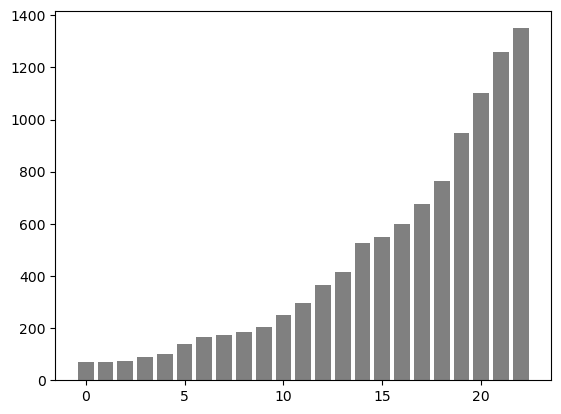

In [24]:
plt.bar( np.arange(baseball_train.shape[0]) , baseball_train['Salary'].sort_values(ascending = True), color = 'gray')

This is the distribution of the salary column, it is ascending and skewed to the right. The distribution of salary with or without null is the same. 
We must try to keep the data description and distribution, by filling in the null values with some values.

In [26]:
# Sample from existing values
baseball_train.loc[baseball_train['Salary'].isna(), 'Salary'] = baseball_train['Salary'].dropna().sample(baseball_train['Salary'].isna().sum(), replace=True, random_state =24432).values

In [27]:
baseball_train["Salary"].describe()

count      35.000000
mean      432.476200
std       368.844606
min        70.000000
25%       120.000000
50%       365.000000
75%       637.500000
max      1350.000000
Name: Salary, dtype: float64

<BarContainer object of 35 artists>

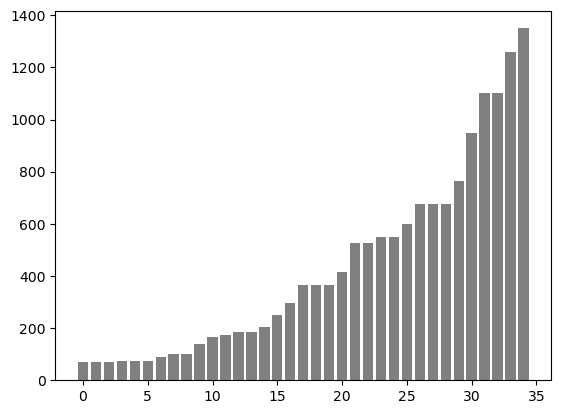

In [28]:
#plt.bar( np.arange(23) , baseball_train[~baseball_train["Salary"].isna()]['Salary'].sort_values(ascending = True), color = 'gray')
plt.bar( np.arange(baseball_train.shape[0]) , baseball_train['Salary'].sort_values(ascending = True), color = 'gray')

As we can see, the data is skewed. 

## 1.4 Target Variable Exploration

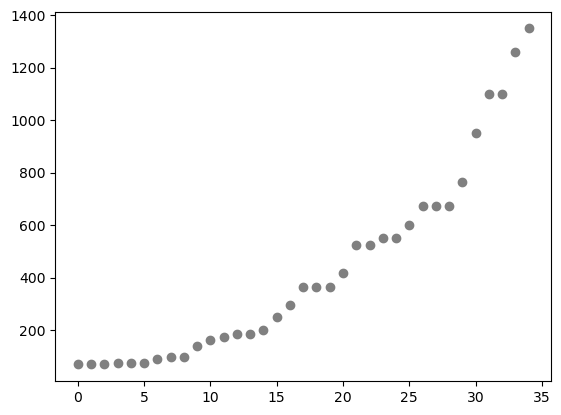

In [31]:
plt.scatter( np.arange(baseball_train.shape[0]) , baseball_train['Salary'].sort_values(ascending = True), color = 'gray')

The salary is skewed to the right. This will negatively affect our linear regression. Let us try and smooth out our data with log transform

In [33]:
baseball_train['LogSalary'] = np.log(baseball_train['Salary'])

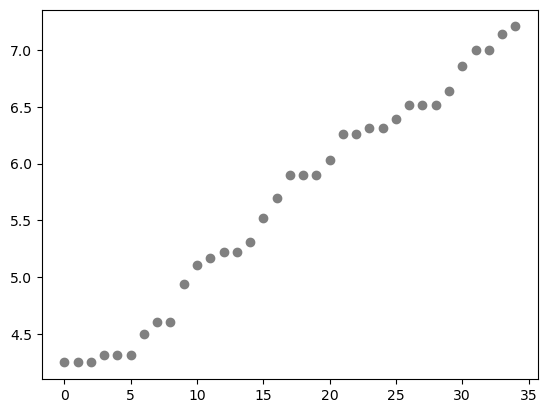

In [34]:
plt.scatter( np.arange(baseball_train.shape[0]) , baseball_train['LogSalary'].sort_values(ascending = True), color = 'gray')

Now the salary is ready to be fit in a linear regression, but must be changed back to regular salary before the mean squared error and/or gradient descent calculations.

## 1.5 Correlations

### 1.5.1 Correlations of Number Columns

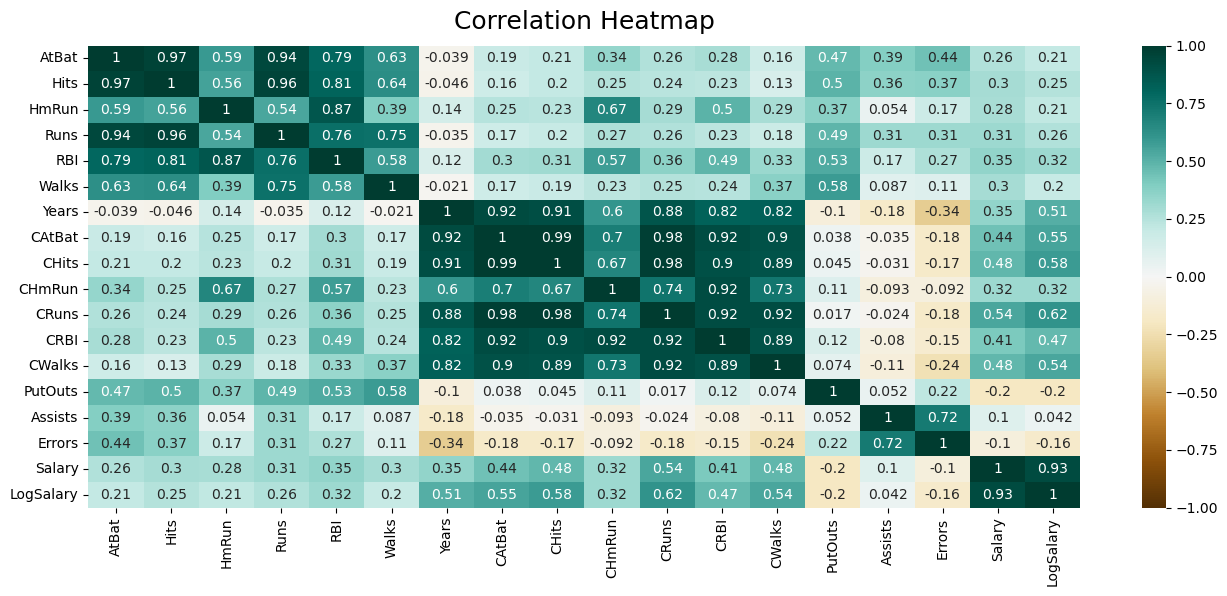

In [38]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(baseball_train.select_dtypes('number').corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12);
# save heatmap as .png file
# dpi - sets the resolution of the saved image in dots/inches
# bbox_inches - when set to 'tight' - does not allow the labels to be cropped
#plt.savefig('/work/heatmap.png', dpi=300, bbox_inches='tight')

Years: CAtBat, CHits, CRuns, CRBI, CWalks

Log/Salary: CAtBat, CHits, CHmRun, CRuns, CRBI, CWalks


## 1.6 Target Distribution Across Features

### 1.6.1 Target Distribution Across Numeric

Text(0.5, 1.0, 'Salary vs Hits')

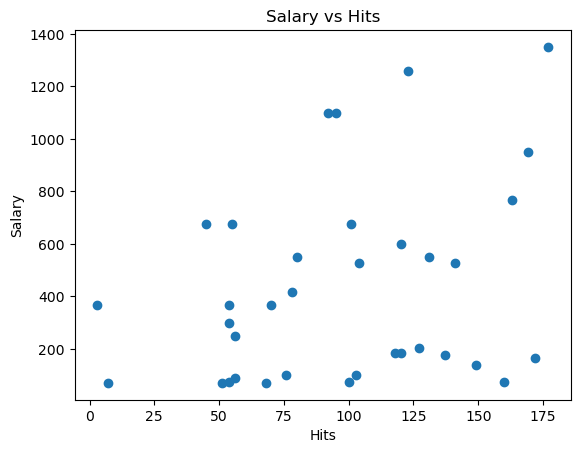

In [42]:
#Shows the correlation between salary and hits
plt.scatter(baseball_train['Hits'], baseball_train['Salary'])
plt.xlabel('Hits')
plt.ylabel('Salary')
plt.title('Salary vs Hits')

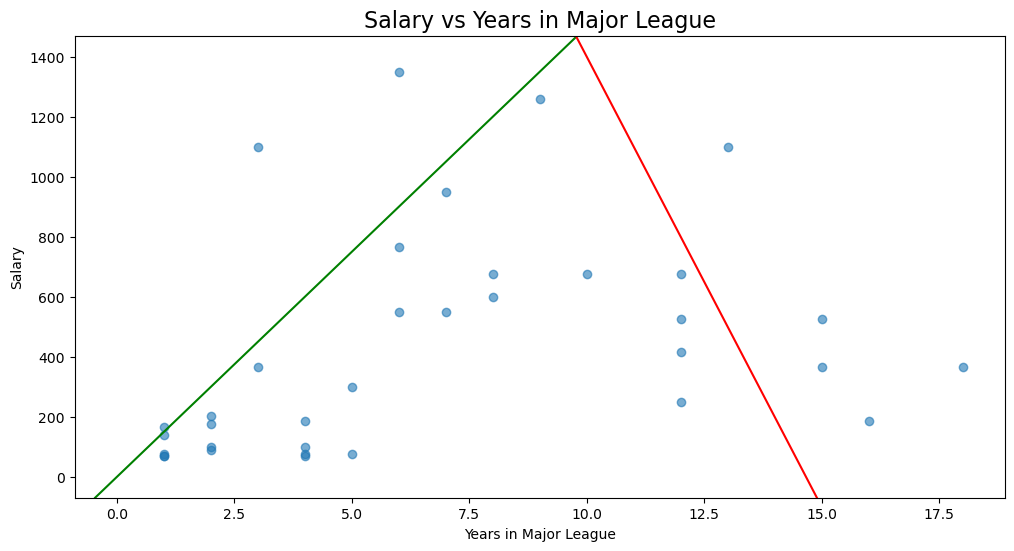

In [43]:
#Shows the correlation between years on team and pay

plt.figure(figsize=(12, 6))

plt.scatter(baseball_train['Years'], baseball_train['Salary'], alpha=0.6)
plt.title('Salary vs Years in Major League', fontsize=16)
plt.axline((0,0), slope = 150, color = 'g')
plt.axline((10, 1400), slope = -300, color ='r')
plt.xlabel('Years in Major League')
plt.ylabel('Salary')

plt.show()


### 1.6.2 Target Distribution Across Categorical

<Axes: title={'center': 'Salary'}, xlabel='NewLeague'>

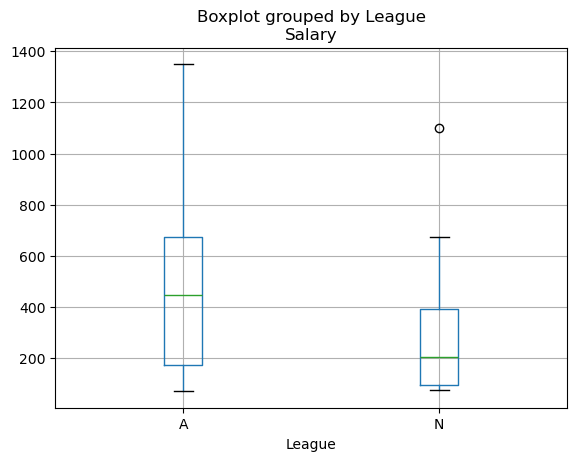

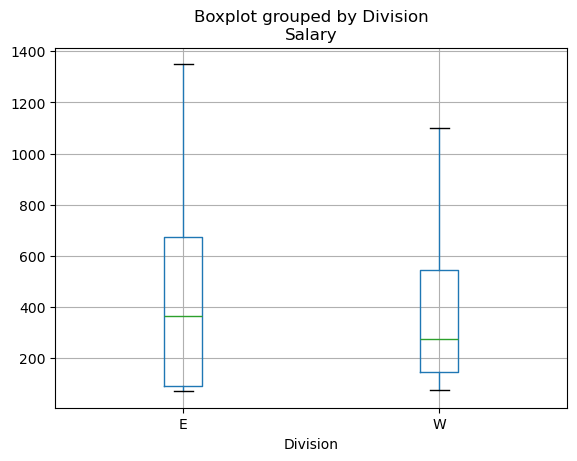

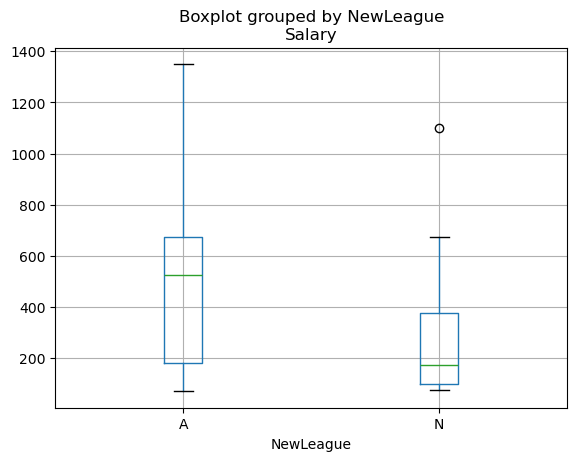

In [45]:
#Visualized boxplot diagram sorting the salary's by division
baseball_train.boxplot(column='Salary', by='League')
baseball_train.boxplot(column='Salary', by='Division')
baseball_train.boxplot(column='Salary', by='NewLeague')

In [46]:
#Changing the type to category for better assortment 
player_div_category = ['League','Division', 'NewLeague']
for cat in player_div_category:
    baseball_train[cat] = baseball_train[cat].astype('category')
    baseball_test[cat] = baseball_test[cat].astype('category')

## 1.7 Conclusion

The features that matter the most for our dataset would be the categoricals (League, NewLeague, Division), certain numerics (Years, Cruns, etc), and derived features . We should not take two features that mention the same thing, i.e. Runs vs CRuns, ...

The salary tiers will be helpful when applying the ML technique of classification prediction onto our dataset. However, it is not our main predictive model, only a side, helpful one. 

Someh features may require transformatig, such as the categorical/object columns. They will be used in any modeling technique. We may also derive features to be used in our models. From different features that are correlated with each other.


# Salary Tier Classification

In [52]:
# Salary Tiers for Classification
#baseball_train['SalaryTiers'] = pd.qcut(baseball_train['Salary'], q=4,labels=['Low', 'Medium', 'High']) # Must do 0-25%, 25-50%. 50-75%, 75-infinity

## Encoding Categorical Variables

In [54]:
df.print()
categorical_cols = ["League", "Division", "NewLeague"] # Transform the categorical features 
mapping = {"A": 0, "N": 1, "E": 0, "W": 1}

for col in categorical_cols:
    df[col] = df[col].map(mapping)

NameError: name 'df' is not defined

## Outputs regression/classification datasets

In [ ]:
df_regression = df.drop(columns=["SalaryTier"])
df_classification = df.drop(columns=["LogSalary"]) 

df_regression.to_csv("Baseball_regression.csv", index=False)
df_classification.to_csv("Baseball_classification.csv", index=False)
# This can be helpful later... when working with team